In [1]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import zscore

from tqdm import tqdm

import xml.etree.ElementTree as ET
from tifffile import imread
from tifffile import TiffFile

from skimage.color import rgb2gray
from skimage.color import label2rgb
from skimage.transform import rescale
from skimage.exposure import rescale_intensity, equalize_adapthist
from skimage.measure import regionprops
from skimage.measure import regionprops_table
from skimage.segmentation import mark_boundaries
from skimage.filters import gaussian, median

from skimage.morphology import white_tophat, disk

# stardist
from csbdeep.utils import normalize
from stardist.models import StarDist2D

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2026-03-12 12:54:56.898981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
_OME_NS = {"ome": "http://www.openmicroscopy.org/Schemas/OME/2016-06"}

def load_ome_physical_info(fpath):
    """Return (info: dict, pixels_to_physical: callable) and print a summary."""
    with TiffFile(fpath) as tif:
        ome_xml = tif.ome_metadata
        dtype = tif.pages[0].dtype if tif.pages else None

    root = ET.fromstring(ome_xml)

    # Core Pixels block
    px = root.find(".//ome:Image/ome:Pixels", _OME_NS)
    sizeX = int(px.get("SizeX"))
    sizeY = int(px.get("SizeY"))
    sizeZ = int(px.get("SizeZ", 1))
    sizeC = int(px.get("SizeC", 1))
    sizeT = int(px.get("SizeT", 1))
    dim_order = px.get("DimensionOrder")
    dtype_xml = px.get("Type")

    # Physical sizes (+ units if present; OME often omits => assume µm)
    sx = float(px.get("PhysicalSizeX"))
    sy = float(px.get("PhysicalSizeY"))
    sx_unit = px.get("PhysicalSizeXUnit") or "µm"
    sy_unit = px.get("PhysicalSizeYUnit") or "µm"

    # Optional global origin: Plate origin + WellSample position (if present)
    plate = root.find(".//ome:Plate", _OME_NS)
    well_sample = root.find(".//ome:Well/ome:WellSample", _OME_NS)

    well_origin_x = float(plate.get("WellOriginX")) if plate is not None and plate.get("WellOriginX") else 0.0
    well_origin_y = float(plate.get("WellOriginY")) if plate is not None and plate.get("WellOriginY") else 0.0
    pos_x = float(well_sample.get("PositionX")) if well_sample is not None and well_sample.get("PositionX") else 0.0
    pos_y = float(well_sample.get("PositionY")) if well_sample is not None and well_sample.get("PositionY") else 0.0

    origin_x = well_origin_x + pos_x
    origin_y = well_origin_y + pos_y
    origin_unit = "µm"  # OME positions default to µm unless specified otherwise

    # Channels (names)
    ch_names = [
        ch.get("Name") or f"Channel-{i}"
        for i, ch in enumerate(root.findall(".//ome:Image/ome:Pixels/ome:Channel", _OME_NS))
    ]

    # Acquisition date (optional)
    acq = root.find(".//ome:Image/ome:AcquisitionDate", _OME_NS)
    acq_time = acq.text if acq is not None else None

    info = {
        "size": {"X": sizeX, "Y": sizeY, "Z": sizeZ, "C": sizeC, "T": sizeT},
        "dimension_order": dim_order,
        "dtype_xml": dtype_xml,
        "dtype_tiff": str(dtype) if dtype is not None else None,
        "physical_pixel_size": {"X": sx, "X_unit": sx_unit, "Y": sy, "Y_unit": sy_unit},
        "origin": {"X": origin_x, "Y": origin_y, "unit": origin_unit,
                   "components": {"WellOriginX": well_origin_x, "WellOriginY": well_origin_y,
                                  "PositionX": pos_x, "PositionY": pos_y}},
        "channels": ch_names,
        "acquisition_time": acq_time,
    }

    # Pretty print
    print("=== OME Physical Metadata ===")
    print(f"Size (XYZCT): {sizeX} x {sizeY} x {sizeZ} x {sizeC} x {sizeT}  |  Order: {dim_order}")
    print(f"DType (OME/TIFF): {dtype_xml} / {info['dtype_tiff']}")
    print(f"Pixel size: X={sx} {sx_unit}  Y={sy} {sy_unit}")
    print(f"Origin (best-effort): X={origin_x:.3f} {origin_unit}, Y={origin_y:.3f} {origin_unit}")
    print(f"  Components: WellOrigin=({well_origin_x}, {well_origin_y}), "
          f"Position=({pos_x}, {pos_y}) [{origin_unit}]")
    print(f"Channels ({len(ch_names)}): {', '.join(ch_names) if ch_names else '—'}")
    print(f"Acquired: {acq_time}")
    print("=============================")

    # Mapper
    def pixels_to_physical(ix, iy):
        """Map pixel indices (ix, iy) -> physical coords (X, Y) in origin_unit."""
        return origin_x + ix * sx, origin_y + iy * sy

    return info, pixels_to_physical

# ---- usage ----
fpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/test/test-scene5-wellB6_s5.ome.tiff"
info, p2p = load_ome_physical_info(fpath)

# Example: top-left (0,0) and center pixel
x0, y0 = p2p(0, 0)
xc, yc = p2p(info["size"]["X"] // 2, info["size"]["Y"] // 2)
print(f"Example coords: (0,0) -> ({x0:.3f}, {y0:.3f}) {info['origin']['unit']}")
print(f"Center pixel -> ({xc:.3f}, {yc:.3f}) {info['origin']['unit']}")

=== OME Physical Metadata ===
Size (XYZCT): 498 x 368 x 1 x 9 x 1  |  Order: XYZTC
DType (OME/TIFF): uint8 / uint8
Pixel size: X=2.724 µm  Y=2.724 µm
Origin (best-effort): X=49428.137 µm, Y=17654.152 µm
  Components: WellOrigin=(-9900.0, -2750.0), Position=(59328.1367, 20404.1523) [µm]
Channels (3): H3342, AF488, AF594
Acquired: 2026-03-04T18:04:55.1451862Z
Example coords: (0,0) -> (49428.137, 17654.152) µm
Center pixel -> (50106.413, 18155.368) µm


In [3]:
%%time
fpath = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/test/test-scene5-wellB6_s5.ome.tiff"
img = imread(fpath)

print(f"{img.shape=} {img.dtype=}")

<tifffile.TiffFrame 3 @646514> is missing required tags
<tifffile.TiffFile 'test-scene5-wellB6_s5.ome.tiff'> OME series expected 3 frames, got 4


img.shape=(3, 368, 498, 3) img.dtype=dtype('uint8')
CPU times: user 14.6 ms, sys: 5.54 ms, total: 20.2 ms
Wall time: 29.8 ms


img.shape=(3, 368, 498, 3)


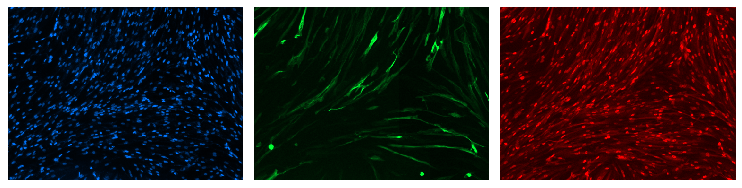

In [4]:
print(f"{img.shape=}")

dpi = 75

plt.rcParams['figure.dpi'] = dpi
plt.rcParams['figure.figsize'] = 10, 8

# plt.imshow(img[0, :, :, :], interpolation='nearest')
# plt.axis(False)

fig, axes = plt.subplots(1, 3)

for i in range(3):
    axes[i].imshow(img[i, :, :, :], interpolation='nearest')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# print(f"Shape: {img.shape}")   # (3, 368, 498, 3)
# print(f"Dtype: {img.dtype}")   # likely uint8 or uint16

# # Peek at the RGB values — are all 3 RGB values identical per pixel?
# # If so, it's grayscale stored as RGB (very common in OME-TIFF)
# c = 0
# sample_plane = img[c]  # shape (368, 498, 3)

# # Check if R == G == B across the plane
# is_redundant_rgb = np.allclose(sample_plane[..., 0],
#                                 sample_plane[..., 1]) and \
#                    np.allclose(sample_plane[..., 1],
#                                 sample_plane[..., 2])

# print(f"RGB channels identical (grayscale-as-RGB)? {is_redundant_rgb}")

Shape: (3, 368, 498, 3)
Dtype: uint8
RGB channels identical (grayscale-as-RGB)? False


In [23]:
for c in range(img.shape[0]):
    print(f"\nCh {c} ({info['channels'][c]}):")
    for rgb, name in enumerate(["R", "G", "B"]):
        plane = img[c, :, :, rgb]
        print(f"  {name}: min={plane.min()}, max={plane.max()}, "
              f"mean={plane.mean():.2f}, nonzero={np.count_nonzero(plane)}")


Ch 0 (H3342):
  R: min=0, max=0, mean=0.00, nonzero=0
  G: min=1, max=117, mean=15.68, nonzero=183264
  B: min=2, max=254, mean=34.10, nonzero=183264

Ch 1 (AF488):
  R: min=0, max=0, mean=0.00, nonzero=0
  G: min=4, max=254, mean=21.60, nonzero=183264
  B: min=0, max=50, mean=3.92, nonzero=183257

Ch 2 (AF594):
  R: min=23, max=254, mean=70.37, nonzero=183264
  G: min=0, max=0, mean=0.00, nonzero=0
  B: min=0, max=0, mean=0.00, nonzero=0


In [24]:
# def extract_grayscale(img):
#     """
#     Extract grayscale from (C, Y, X, 3) using the appropriate method per channel.
#     rgb2gray uses ITU-R 601-2 luma transform: 0.2126R + 0.7152G + 0.0722B
#     Output is scaled back to original dtype range.
#     """
#     gray_channels = []
#     vmax = np.iinfo(img.dtype).max

#     for c in range(img.shape[0]):
#         plane = img[c]  # (Y, X, 3)
#         gray  = rgb2gray(plane)           # float64 in [0, 1]
#         gray  = (gray * vmax).astype(img.dtype)
#         gray_channels.append(gray)

#         print(f"Ch {c} ({info['channels'][c]}): "
#               f"min={gray.min()}, max={gray.max()}, "
#               f"mean={gray.mean():.2f}, nonzero={np.count_nonzero(gray)}")

#     return np.stack(gray_channels, axis=0)  # (C, Y, X)

# img_gray = extract_grayscale(img)
# print(f"\nGrayscale shape: {img_gray.shape}")  # (3, 368, 498)

Ch 0 (H3342): min=0, max=102, mean=13.20, nonzero=182900
Ch 1 (AF488): min=2, max=185, mean=15.27, nonzero=183264
Ch 2 (AF594): min=4, max=53, mean=14.45, nonzero=183264

Grayscale shape: (3, 368, 498)


In [7]:
# # rgb2gray expects (..., 3) as last dim — works directly here
# img_gray = np.stack(
#     [rgb2gray(img[c]) for c in range(img.shape[0])],
#     axis=0
# )
# # rgb2gray outputs float64 in [0,1] — rescale back to original dtype range
# if img.dtype == np.uint8:
#     img_gray = (img_gray * 255).astype(np.uint8)
# elif img.dtype == np.uint16:
#     img_gray = (img_gray * 65535).astype(np.uint16)

# print(f"Grayscale shape: {img_gray.shape}")  # (3, 368, 498)

Grayscale shape: (3, 368, 498)


In [9]:
# # background subtraction (rolling ball, radius - 10 pixels)
# def subtract_rolling_ball_2d(img, radius=50):
#     """
#     Rolling ball background subtraction for shape (C, Y, X).

#     Parameters
#     ----------
#     img    : ndarray, shape (C, Y, X)
#     radius : int, rolling ball radius in pixels

#     Returns
#     -------
#     corrected   : ndarray, same shape/dtype as img
#     backgrounds : ndarray, same shape as img
#     """
#     assert img.ndim == 3, f"Expected (C, Y, X), got {img.shape}"
#     selem = disk(radius)
#     corrected   = np.zeros_like(img)
#     backgrounds = np.zeros_like(img)

#     for c in tqdm(range(img.shape[0]), desc="Channels"):
#         plane = img[c]                               # (Y, X)
#         bg    = plane - white_tophat(plane, selem)   # estimate background
#         corr  = np.clip(
#                     plane.astype(np.int32) - bg.astype(np.int32),
#                     0, None
#                 )
#         corrected[c]   = corr.astype(img.dtype)
#         backgrounds[c] = bg.astype(img.dtype)

#     return corrected, backgrounds

In [10]:
# radius_px = 10

# corrected_img, backgrounds = subtract_rolling_ball_2d(img_gray, radius=radius_px)

Channels: 100%|██████████| 3/3 [00:00<00:00,  6.56it/s]


In [ ]:
# def plot_correction_qc(img_raw, img_corr, img_bg, channel_names=None):
#     """QC grid: Raw | Background | Corrected — for (C, Y, X) arrays."""
#     nC = img_raw.shape[0]
#     fig, axes = plt.subplots(nC, 3, figsize=(12, 4 * nC))

#     for c in range(nC):
#         name = channel_names[c] if channel_names else f"Ch {c}"
#         for ax, data, title in zip(
#             axes[c],
#             [img_raw[c], img_bg[c], img_corr[c]],
#             [f"{name}\nRaw", "Background", "Corrected"]
#         ):
#             im = ax.imshow(data, cmap="gray", interpolation="nearest")
#             ax.set_title(title, fontsize=10)
#             ax.axis("off")
#             plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

#     plt.tight_layout()
#     plt.show()

# # ---- usage ----
# plot_correction_qc(img_gray, corrected_img, backgrounds,
#                    channel_names=info["channels"])

In [12]:
# def subtract_rolling_ball_rgb(img, radius=10):
#     """
#     Rolling ball background subtraction for shape (C, Y, X, RGB).
#     Processes each RGB sub-channel independently per fluorescence channel.

#     Parameters
#     ----------
#     img    : ndarray, shape (C, Y, X, 3)
#     radius : int, rolling ball radius in pixels

#     Returns
#     -------
#     corrected   : ndarray, same shape/dtype as img
#     backgrounds : ndarray, same shape as img
#     """
#     assert img.ndim == 4 and img.shape[-1] == 3, f"Expected (C, Y, X, 3), got {img.shape}"
#     selem = disk(radius)
#     corrected   = np.zeros_like(img)
#     backgrounds = np.zeros_like(img)

#     for c in tqdm(range(img.shape[0]), desc="Channels"):
#         for rgb in range(3):  # R, G, B
#             plane = img[c, :, :, rgb]                    # (Y, X)
#             bg    = plane - white_tophat(plane, selem)
#             corr  = np.clip(
#                         plane.astype(np.int32) - bg.astype(np.int32),
#                         0, None
#                     )
#             corrected[c, :, :, rgb]   = corr.astype(img.dtype)
#             backgrounds[c, :, :, rgb] = bg.astype(img.dtype)

#     return corrected, backgrounds


# # ---- usage ----
# radius_px = 10
# corrected_img, backgrounds = subtract_rolling_ball_rgb(img, radius=radius_px)

Channels: 100%|██████████| 3/3 [00:01<00:00,  2.21it/s]


In [ ]:
# def plot_correction_qc_rgb(img_raw, img_corr, img_bg, channel_names=None):
#     """
#     QC grid: Raw | Background | Corrected — for (C, Y, X, 3) arrays.
#     Displayed in original RGB colors.
#     """
#     nC = img_raw.shape[0]
#     fig, axes = plt.subplots(nC, 3, figsize=(12, 4 * nC))

#     for c in range(nC):
#         name = channel_names[c] if channel_names else f"Ch {c}"

#         # Normalize to [0, 1] for imshow — handles uint8 and uint16
#         vmax = np.iinfo(img_raw.dtype).max

#         for ax, data, title in zip(
#             axes[c],
#             [img_raw[c], img_bg[c], img_corr[c]],
#             [f"{name}\nRaw", "Background", "Corrected"]
#         ):
#             ax.imshow(data / vmax, interpolation="nearest")  # RGB — no cmap
#             ax.set_title(title, fontsize=10)
#             ax.axis("off")

#     plt.suptitle(f"Rolling Ball QC  (radius={radius_px} px)", y=1.01)
#     plt.tight_layout()
#     plt.show()


# # ---- usage ----
# plot_correction_qc_rgb(img, corrected_img, backgrounds,
#                        channel_names=info["channels"])

In [ ]:
# print(corrected_img.shape)

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = 10, 8

# fig, axes = plt.subplots(1, 3)

# for i in range(3):
#     axes[i].imshow(corrected_img[i, :, :, :], interpolation='nearest')
#     axes[i].axis('off')

# plt.tight_layout()
# plt.show()

In [ ]:
# def add_scale_bar(ax, pixel_size_um, image_width_px, 
#                   bar_um=50, color="white", fontsize=8):
#     """
#     Add a scale bar to a matplotlib axis.

#     Parameters
#     ----------
#     ax             : matplotlib axis
#     pixel_size_um  : float, physical size of one pixel in µm
#     image_width_px : int, width of the image in pixels (for positioning)
#     bar_um         : float, desired scale bar length in µm
#     color          : str, color of the scale bar and label
#     fontsize       : int, font size of the label
#     """
#     bar_px = bar_um / pixel_size_um  # convert µm → pixels

#     # Position: bottom-right corner with a small margin
#     margin_x = image_width_px * 0.04
#     margin_y = image_width_px * 0.04
#     x_end    = image_width_px - margin_x
#     x_start  = x_end - bar_px
#     y_pos    = corrected_img.shape[1] - margin_y  # near bottom

#     ax.plot([x_start, x_end], [y_pos, y_pos],
#             color=color, linewidth=2, solid_capstyle="butt")
    # ax.text((x_start + x_end) / 2, y_pos - margin_y * 0.6,
    #         f"{bar_um} µm",
    #         color=color, fontsize=fontsize,
    #         ha="center", va="bottom")
    
    
# pixel_size_um  = info["physical_pixel_size"]["X"]  # µm per pixel
# image_width_px = corrected_img.shape[2]            # X dimension

# scale_bar_length = 100 # microns

# plt.rcParams['figure.dpi']    = 300
# plt.rcParams['figure.figsize'] = 10, 8

# fig, axes = plt.subplots(1, 3)

# for i in range(3):
#     axes[i].imshow(corrected_img[i, :, :, :], interpolation='nearest')
#     axes[i].axis('off')
#     add_scale_bar(axes[i],
#                   pixel_size_um  = pixel_size_um,
#                   image_width_px = image_width_px,
#                   bar_um         = scale_bar_length,    
#                   color          = "white",
#                   fontsize       = 8)

# plt.tight_layout()
# plt.show()

In [7]:
def extract_grayscale(img):
    """
    Extract grayscale from (C, Y, X, 3) using the appropriate method per channel.
    rgb2gray uses ITU-R 601-2 luma transform: 0.2126R + 0.7152G + 0.0722B
    Output is scaled back to original dtype range.
    """
    gray_channels = []
    vmax = np.iinfo(img.dtype).max

    for c in range(img.shape[0]):
        plane = img[c]  # (Y, X, 3)
        gray  = rgb2gray(plane)           # float64 in [0, 1]
        gray  = (gray * vmax).astype(img.dtype)
        gray_channels.append(gray)

        print(f"Ch {c} ({info['channels'][c]}): "
              f"min={gray.min()}, max={gray.max()}, "
              f"mean={gray.mean():.2f}, nonzero={np.count_nonzero(gray)}")

    return np.stack(gray_channels, axis=0)  # (C, Y, X)


def subtract_rolling_ball_2d(img, radius=10):
    """
    Rolling ball background subtraction for shape (C, Y, X).

    Parameters
    ----------
    img    : ndarray, shape (C, Y, X)
    radius : int, rolling ball radius in pixels

    Returns
    -------
    corrected   : ndarray, same shape/dtype as img
    backgrounds : ndarray, same shape as img
    """
    assert img.ndim == 3, f"Expected (C, Y, X), got {img.shape}"
    selem = disk(radius)
    corrected   = np.zeros_like(img)
    backgrounds = np.zeros_like(img)

    for c in tqdm(range(img.shape[0]), desc="Channels"):
        plane = img[c]
        bg    = plane - white_tophat(plane, selem)
        corr  = np.clip(
                    plane.astype(np.int32) - bg.astype(np.int32),
                    0, None
                )
        corrected[c]   = corr.astype(img.dtype)
        backgrounds[c] = bg.astype(img.dtype)

    return corrected, backgrounds


def build_composite(corrected_gray, channel_colors):
    """
    Build a true composite image from grayscale channels and LUT colors.

    Parameters
    ----------
    corrected_gray  : ndarray, shape (C, Y, X)
    channel_colors  : list of arrays, each shape (3,) — RGB color per channel

    Returns
    -------
    composite : ndarray, shape (Y, X, 3), float32 in [0, 1]
    """
    composite = np.zeros((*corrected_gray.shape[1:], 3), dtype=np.float32)

    for c, color in enumerate(channel_colors):
        plane      = corrected_gray[c].astype(np.float32)
        plane_norm = plane / plane.max()                        # normalize to [0, 1]
        composite += plane_norm[..., np.newaxis] * color        # colorize and add

    return np.clip(composite, 0, 1)


def add_scale_bar(ax, pixel_size_um, image_width_px, 
                  bar_um=50, color="white", fontsize=8):
    """
    Add a scale bar to a matplotlib axis.

    Parameters
    ----------
    ax             : matplotlib axis
    pixel_size_um  : float, physical size of one pixel in µm
    image_width_px : int, width of the image in pixels (for positioning)
    bar_um         : float, desired scale bar length in µm
    color          : str, color of the scale bar and label
    fontsize       : int, font size of the label
    """
    bar_px = bar_um / pixel_size_um  # convert µm → pixels

    # Position: bottom-right corner with a small margin
    margin_x = image_width_px * 0.04
    margin_y = image_width_px * 0.04
    x_end    = image_width_px - margin_x
    x_start  = x_end - bar_px
    y_pos    = img.shape[1] - margin_y  # near bottom

    ax.plot([x_start, x_end], [y_pos, y_pos],
            color=color, linewidth=2, solid_capstyle="butt")
    # ax.text((x_start + x_end) / 2, y_pos - margin_y * 0.6,
    #         f"{bar_um} µm",
    #         color=color, fontsize=fontsize,
    #         ha="center", va="bottom")

Ch 0 (H3342): min=0, max=102, mean=13.20, nonzero=182900
Ch 1 (AF488): min=2, max=185, mean=15.27, nonzero=183264
Ch 2 (AF594): min=4, max=53, mean=14.45, nonzero=183264

Grayscale shape: (3, 368, 498)


Channels: 100%|██████████| 3/3 [00:00<00:00,  5.75it/s]


Corrected grayscale shape: (3, 368, 498)

After background subtraction:
Ch 0 (H3342): min=0, max=101, mean=10.52, nonzero=164293
Ch 1 (AF488): min=0, max=180, mean=8.28, nonzero=172729
Ch 2 (AF594): min=0, max=47, mean=6.26, nonzero=168604
Composite shape: (368, 498, 3)


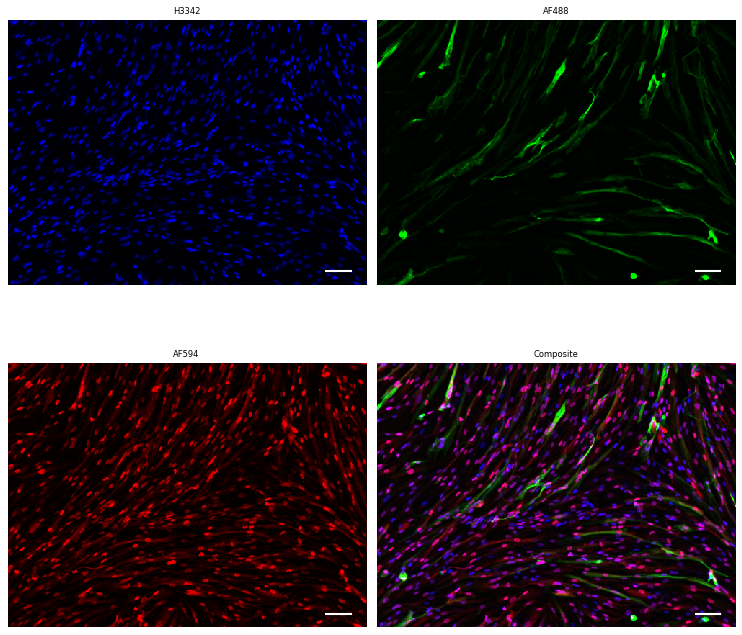

In [8]:
# ---- Step 1: Extract grayscale from (C, Y, X, 3) → (C, Y, X) ----

img_gray = extract_grayscale(img)
print(f"\nGrayscale shape: {img_gray.shape}")  # (3, 368, 498)



# ---- Step 2: Rolling ball background subtraction on grayscale ----

radius_px = 10
corrected_gray, backgrounds_gray = subtract_rolling_ball_2d(img_gray, radius=radius_px)
print(f"Corrected grayscale shape: {corrected_gray.shape}")  # (3, 368, 498)

# Verify no blank channels
print("\nAfter background subtraction:")
for c in range(corrected_gray.shape[0]):
    plane = corrected_gray[c]
    print(f"Ch {c} ({info['channels'][c]}): "
          f"min={plane.min()}, max={plane.max()}, "
          f"mean={plane.mean():.2f}, nonzero={np.count_nonzero(plane)}")
    
    
    
# ---- Step 3: Assign LUT colors and build composite ----

# Customize these to match your stains
lut_colors = {
    "red":     np.array([1, 0, 0]),
    "green":   np.array([0, 1, 0]),
    "blue":    np.array([0, 0, 1]),
    "cyan":    np.array([0, 1, 1]),
    "magenta": np.array([1, 0, 1]),
    "yellow":  np.array([1, 1, 0]),
    "gray":    np.array([1, 1, 1]),
}

# Assign a color to each channel — adjust to your stains
channel_colors = [
    lut_colors["blue"],    # Ch0 — e.g. DAPI
    lut_colors["green"],   # Ch1 — e.g. GFP
    lut_colors["red"],     # Ch2 — e.g. mCherry
]

composite = build_composite(corrected_gray, channel_colors)
print(f"Composite shape: {composite.shape}")  # (368, 498, 3)



# ---- Step 4: Plot individual corrected channels + composite ----
pixel_size_um  = info["physical_pixel_size"]["X"]
image_width_px = composite.shape[1]
scale_bar_length = 100 # microns


fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=dpi)
axes = axes.ravel()

for c in range(3):
    # Display each channel colorized individually
    plane_norm = corrected_gray[c].astype(np.float32) / corrected_gray[c].max()
    colorized  = np.clip(
                     plane_norm[..., np.newaxis] * channel_colors[c],
                     0, 1
                 )
    axes[c].imshow(colorized, interpolation='nearest')
    axes[c].set_title(info["channels"][c], fontsize=8)
    axes[c].axis('off')
    add_scale_bar(axes[c], pixel_size_um, image_width_px, bar_um=scale_bar_length)

# Composite
axes[3].imshow(composite, interpolation='nearest')
axes[3].set_title("Composite", fontsize=8)
axes[3].axis('off')
add_scale_bar(axes[3], pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()

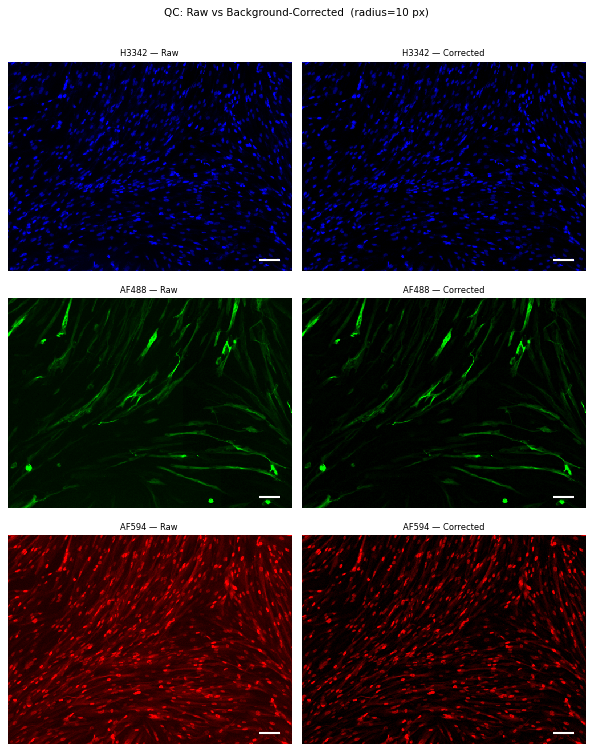

In [9]:
# ---- QC Plot: Raw vs Corrected per channel ----

fig, axes = plt.subplots(3, 2, figsize=(8, 10), dpi=dpi)

for c in range(3):
    # Raw colorized
    raw_plane = img_gray[c].astype(np.float32)
    raw_max   = raw_plane.max()
    raw_norm  = raw_plane / raw_max if raw_max > 0 else raw_plane
    raw_colorized = np.clip(raw_norm[..., np.newaxis] * channel_colors[c], 0, 1)

    # Corrected colorized
    corr_plane = corrected_gray[c].astype(np.float32)
    corr_max   = corr_plane.max()
    corr_norm  = corr_plane / corr_max if corr_max > 0 else corr_plane
    corr_colorized = np.clip(corr_norm[..., np.newaxis] * channel_colors[c], 0, 1)

    # Plot
    axes[c, 0].imshow(raw_colorized, interpolation='nearest')
    axes[c, 0].set_title(f"{info['channels'][c]} — Raw", fontsize=8)
    axes[c, 0].axis('off')
    add_scale_bar(axes[c, 0], pixel_size_um, image_width_px, bar_um=scale_bar_length)

    axes[c, 1].imshow(corr_colorized, interpolation='nearest')
    axes[c, 1].set_title(f"{info['channels'][c]} — Corrected", fontsize=8)
    axes[c, 1].axis('off')
    add_scale_bar(axes[c, 1], pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.suptitle(f"QC: Raw vs Background-Corrected  (radius={radius_px} px)", 
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
print(corrected_gray.shape)

(3, 368, 498)


(3, 150, 175)
Composite shape: (150, 175, 3)


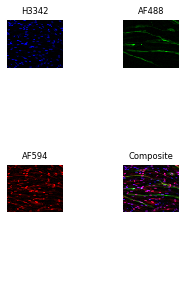

In [10]:
cropped_img = corrected_gray[:, 200:350, 275:450]
print(cropped_img.shape)

composite_crop = build_composite(cropped_img, channel_colors)
print(f"Composite shape: {composite_crop.shape}")


# ---- Step 4: Plot individual corrected channels + composite ----
pixel_size_um  = info["physical_pixel_size"]["X"]
image_width_px = composite_crop.shape[1]
scale_bar_length = 50 # microns


fig, axes = plt.subplots(2, 2, figsize=(4, 4), dpi=dpi)
axes = axes.ravel()

for c in range(3):
    # Display each channel colorized individually
    plane_norm = cropped_img[c].astype(np.float32) / cropped_img[c].max()
    colorized  = np.clip(
                     plane_norm[..., np.newaxis] * channel_colors[c],
                     0, 1
                 )
    axes[c].imshow(colorized, interpolation='nearest')
    axes[c].set_title(info["channels"][c], fontsize=8)
    axes[c].axis('off')
    add_scale_bar(axes[c], pixel_size_um, image_width_px, bar_um=scale_bar_length)

# Composite
axes[3].imshow(composite_crop, interpolation='nearest')
axes[3].set_title("Composite", fontsize=8)
axes[3].axis('off')
add_scale_bar(axes[3], pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()

img.shape=(3, 368, 498, 3)


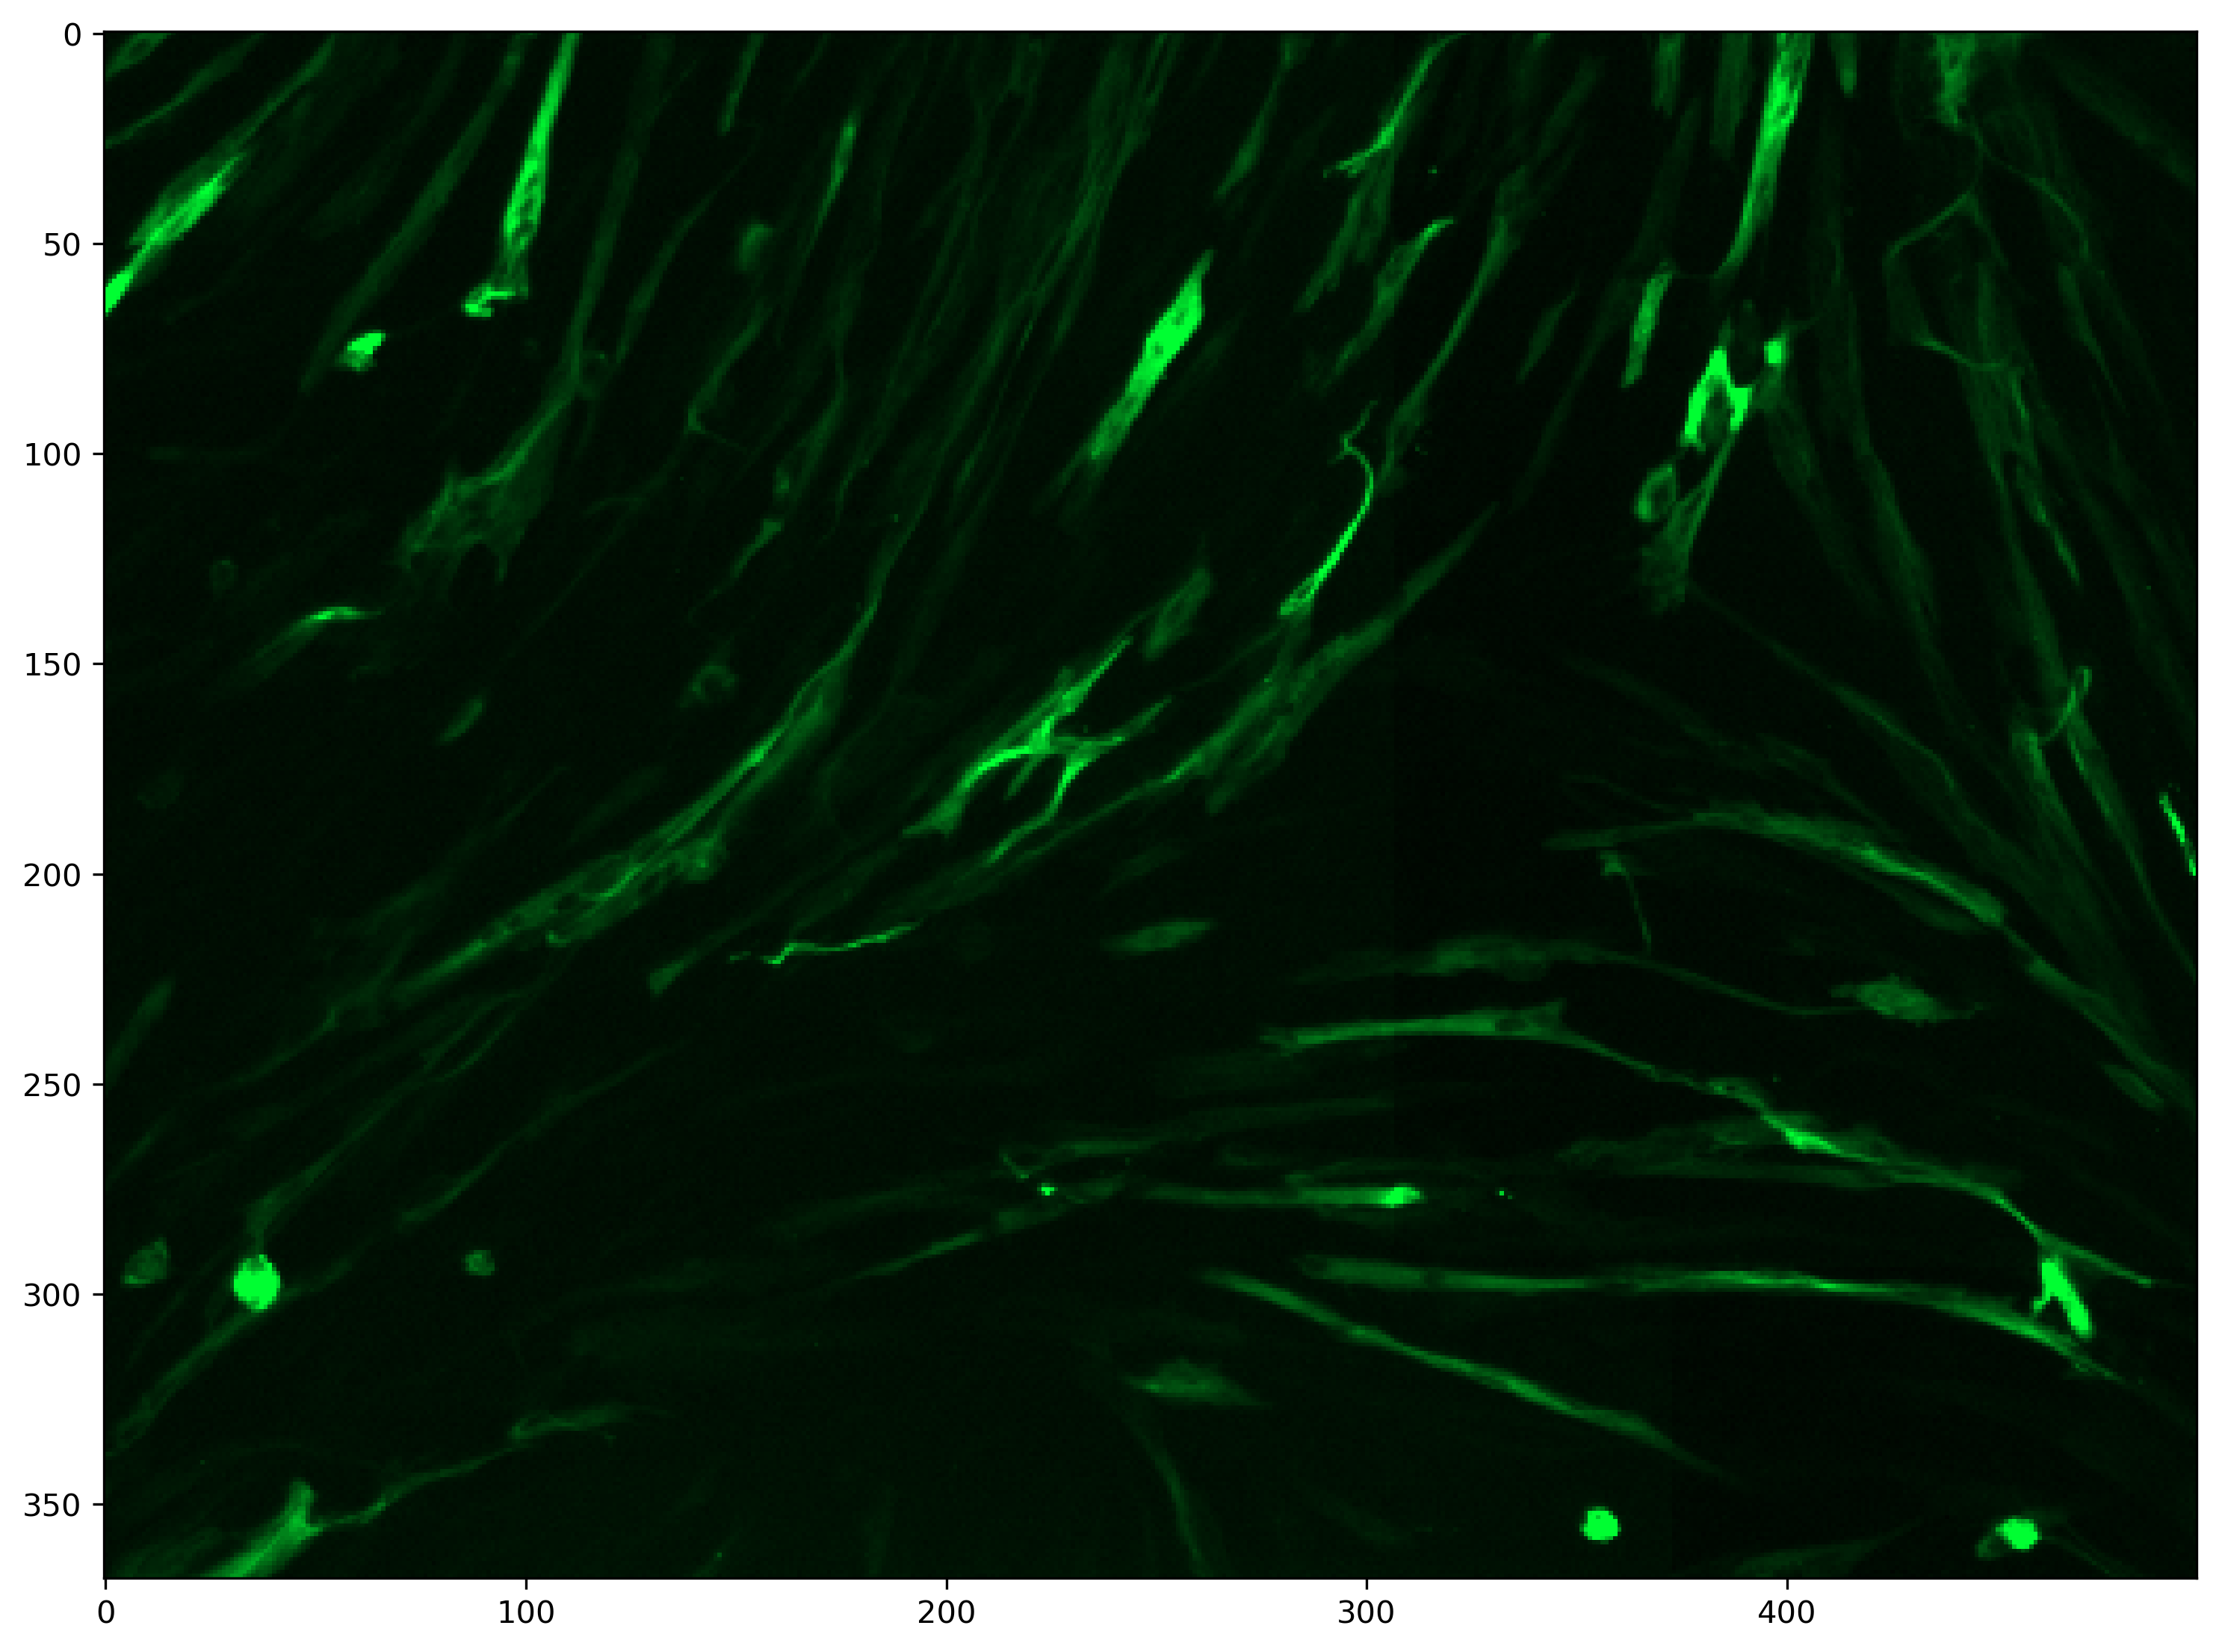

In [11]:
print(f"{img.shape=}")

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 8

plt.imshow(img[1, :, :, :], interpolation='nearest')
# plt.axis(False)

# fig, axes = plt.subplots(1, 3)

# for i in range(3):
#     axes[i].imshow(img[i, :, :, :], interpolation='nearest')
#     axes[i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
%%time
# --- params ---
sigma_bg = 25.0                        # large Gaussian sigma for background
median_footprint = np.ones((5, 5), bool)
use_clahe = False                       # False -> min–max normalize instead
clahe_clip = 0.03                      # typical: 0.01–0.03

C, Y, X, _ = img.shape

# output: uint16, per-channel, per-frame
out_np = np.empty((C, Y, X), dtype=np.uint16)

for c in range(C):

    # ---- 1) grayscale ----
    rgb = img[c]  # (Y, X, 3)
    gray = rgb2gray(rgb).astype(np.float32, copy=False) 
    # gray = color.rgb2gray(rgb)                  # float64 [0,1]
    # gray = gray.astype(np.float32, copy=False)

    # ---- 2) background correction ----
    bg = gaussian(gray, sigma=sigma_bg, preserve_range=True)
    corr = gray - bg
    corr = np.clip(corr, 0, None)

    # ---- 3) median filter ----
    den = median(corr, footprint=median_footprint)

    # ---- 4) contrast enhancement
    if use_clahe:
        enh = equalize_adapthist(den, clip_limit=clahe_clip)
    else:
        vmin = den.min()
        vmax = den.max()
        enh = (den - vmin) / np.maximum(vmax - vmin, np.finfo(np.float32).eps)

    # ---- 5) cast to 16-bit
    out_np[c] = (np.clip(enh, 0, 1) * 65535.0).astype(np.uint16)

    
print(f"{out_np.shape=}")

out_np.shape=(3, 368, 498)
CPU times: user 221 ms, sys: 5.11 ms, total: 226 ms
Wall time: 236 ms


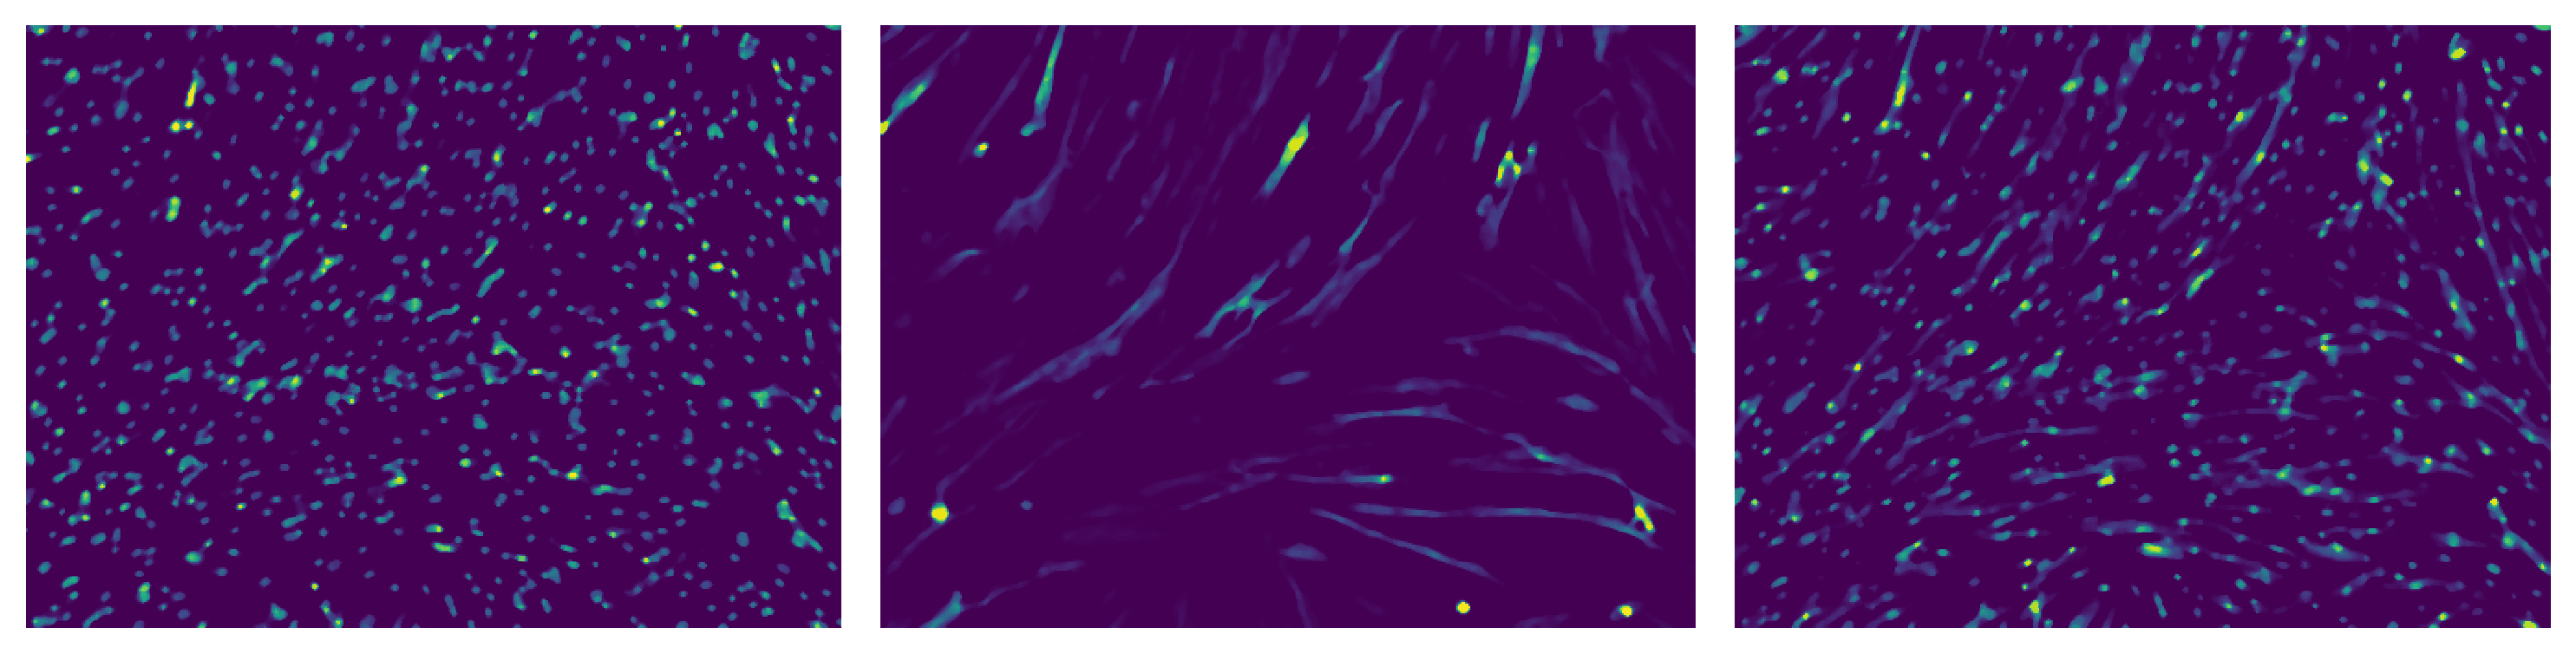

In [21]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 8

C, Y, X = out_np.shape


fig, axes = plt.subplots(1, 3)

for c in range(C):
    axes[c].imshow(out_np[c, :, :], interpolation='nearest')
    axes[c].axis('off')

plt.tight_layout()
plt.show()